# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Image Classification using Global Context Vision Transformer</div></b>

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Initialisation du document</div></b>

In [1]:
import os
# import json
# @param ["tensorflow", "jax", "torch"]
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['KERAS_BACKEND'] = 'tensorflow'  
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ['TF_CPP_MIN_LOG_LEVEL']='5'

import tensorflow as tf, keras, keras_hub
from keras import layers, ops

tf.get_logger().setLevel('ERROR')

E0000 00:00:1757358234.408054  172945 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757358234.413152  172945 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1757358234.425782  172945 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757358234.425795  172945 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757358234.425796  172945 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757358234.425798  172945 computation_placer.cc:177] computation placer already registered. Please check linka

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Import libriries </div></b>

In [2]:
import numpy as np, pandas as pd, seaborn as sns, warnings, os, sys, time
from matplotlib import pyplot as plt

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 : 
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')
    
sns.set(font_scale=2)

print(f"""La version des librairies utilisées :

Tensorflow : {tf.__version__}\tCUDA {tf.test.is_built_with_cuda()}\tGPU {tf.test.is_built_with_gpu_support()}\tXLA {tf.test.is_built_with_xla()}
Keras      : {keras.version()}
Pandas     : {pd.__version__}
NumPy      : {np.__version__}""")

La version des librairies utilisées :

Tensorflow : 2.19.1	CUDA True	GPU True	XLA True
Keras      : 3.12.0
Pandas     : 2.3.2
NumPy      : 2.1.3


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Outils du document</div></b>

In [3]:
sys.path.append(os.path.abspath('../outils/'))

In [4]:
if 'configProjet' in sys.modules.keys():  del(sys.modules['configProjet'])
if 'configModele' in sys.modules.keys():  del(sys.modules['configModele'])

In [5]:
from configProjet import palette, initParametresProjet 
from configProjet import afficheHistoriqueEntrainement, afficheProbabilites, afficheMatriceConfusion, afficheDataset, afficheDistributionsPipe

In [ ]:
from configModele import modelDictionnaire, initParametresExecution, getPipelineDataset
from configModele import creationCompilationModele, creationRappelsExecution, entrainementModele
from configModele import sauvegarderModel, sauvegardeHistorique, executeApprentissageChoixClassifieurs
from configModele import modelCNNSimple, modelPersonalise, modelPersonaliseInception

In [7]:
class DropPath(layers.Layer):
    """Drop Path also known as the Stochastic Depth layer.

    Refernece:
        - https://keras.io/examples/vision/cct/#stochastic-depth-for-regularization
        - github.com:rwightman/pytorch-image-models
    """

    def __init__(self, drop_path_prob, **kwargs):
        super().__init__(**kwargs)
        self.drop_path_prob = drop_path_prob
        self.seed_generator = keras.random.SeedGenerator(1337)

    def call(self, x, training=False):
        if training:
            keep_prob = 1 - self.drop_path_prob
            shape = (ops.shape(x)[0],) + (1,) * (len(ops.shape(x)) - 1)
            random_tensor = keep_prob + keras.random.uniform(
                shape, 0, 1, seed=self.seed_generator
            )
            random_tensor = ops.floor(random_tensor)
            return (x / keep_prob) * random_tensor
        return x


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Introduction</div></b>

Image Classification using Global Context Vision Transformer <br>
In this notebook, we will utilize multi-backend Keras 3.0 to implement the [**GCViT: Global Context Vision Transformer**](https://arxiv.org/abs/2206.09959) paper, presented at ICML 2023 by A Hatamizadeh et al. 

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Motivation</div></b>


> **Note:** In this section we'll learn about the backstory of GCViT and try to
understand why it is proposed.

* During recent years, **Transformers** have achieved dominance in **Natural Language
Processing (NLP)** tasks and with the **self-attention** mechanism which allows for
capturing both long and short-range information.
* Following this trend, **Vision Transformer (ViT)** proposed to utilize image patches as
tokens in a gigantic architecture similar to encoder of the original Transformer.
* Despite the historic dominance of **Convolutional Neural Network (CNN)** in computer
vision, **ViT-based** models have shown **SOTA or competitive performance** in various
computer vision tasks.

<img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/vit_gif.gif" width="512">

* However, **quadratic [`O(n^2)`] computational complexity** of self-attention and **lack
of multi-scale information** makes it difficult for **ViT** to be considered as
general-purpose architecture for Compute Vision tasks like **segmentation and object
detection** where it requires **dense prediction at the pixel level**.

* Swin Transformer has attempted to address the issues of **ViT** by proposing
**multi-resolution/hierarchical** architectures in which the self-attention is computed
in **local windows** and cross-window connections such as **window shifting** are used
for modeling the interactions across different regions. But the **limited receptive field
of local windows** can not capture long-range information, and cross-window-connection
schemes such as **window-shifting only cover a small neighborhood** in the vicinity of
each window. Also, it lacks **inductive-bias** that encourages certain translation
invariance is still preferable for general-purpose visual modeling, particularly for the
dense prediction tasks of object detection and semantic segmentation.

<img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/swin_vs_vit.jpeg" width=400>     

<img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/shifted_window.jpeg" width=400>

<img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/swin_arch.jpeg" width=800>

* To address above limitations, **Global Context (GC) ViT** network is proposed.

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Architecture</div></b>


Let's have a quick **overview** of our key components,
1. `Stem/PatchEmbed:` A stem/patchify layer processes images at the network’s beginning.
For this network, it creates **patches/tokens** and converts them into **embeddings**.
2. `Level:` It is the repetitive building block that extracts features using different
blocks.
3. `Global Token Gen./FeatureExtraction:` It generates **global tokens/patches** with
**Depthwise-CNN**, **SqueezeAndExcitation (Squeeze-Excitation)**, **CNN** and
**MaxPooling**. So basically
it's a Feature Extractor.
4. `Block:` It is the repetitive module that applies attention to the features and
projects them to a certain dimension.
        1. `Local-MSA:` Local Multi head Self Attention.
        2. `Global-MSA:` Global Multi head Self Attention.
        3. `MLP:` Linear layer that projects a vector to another dimension.
5. `Downsample/ReduceSize:` It is very similar to **Global Token Gen.** module except it
uses **CNN** instead of **MaxPooling** to downsample with additional **Layer
Normalization** modules.
6. `Head:` It is the module responsible for the classification task.
    1. `Pooling:` It converts `N x 2D` features to `N x 1D` features.
    2. `Classifier:` It processes `N x 1D` features to make a decision about class.

I've annotated the architecture figure to make it easier to digest,

<a href="https://arxiv.org/pdf/2206.09959"><img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/arch_annot.png"></a>



## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Unit Blocks</div></b>


> **Note:** This blocks are used to build other modules throughout the paper. Most of the
blocks are either borrowed from other work or modified version old work.

1. `SqueezeAndExcitation`: **Squeeze-Excitation (SE)** aka **Bottleneck** module acts sd
kind of **channel
attention**. It consits of **AvgPooling**, **Dense/FullyConnected (FC)/Linear** ,
**GELU** and **Sigmoid** module.
<img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/se_annot.png"
width=400>

2. `Fused-MBConv:` This is similar to the one used in **EfficientNetV2**. It uses
**Depthwise-Conv**, **GELU**, **SqueezeAndExcitation**, **Conv**, to extract feature with
a resiudal
connection. Note that, no new module is declared for this one, we simply applied
corresponding modules directly.
<img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/fmb_annot.png"
width=350>

3. `ReduceSize`: It is a **CNN** based **downsample** module which abvobe mentioned
`Fused-MBConv` module to extract feature, **Strided Conv** to simultaneously reduce
spatial dimension and increse channelwise dimention of the features and finally
**LayerNormalization** module to normalize features. In the paper/figure this module is
referred as **downsample** module. I think it is mention worthy that **SwniTransformer**
used `PatchMerging` module instead of `ReduceSize` to reduce the spatial dimention and
increase channelwise dimension which uses **fully-connected/dense/linear** module.
According to the **GCViT** paper, one of the purposes of using `ReduceSize` is to add
inductive bias through **CNN** module.
<img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/down_annot.png"
width=300>

4. `MLP:` This is our very own **Multi Layer Perceptron** module. This a
feed-forward/fully-connected/linear module which simply projects input to an arbitary
dimension.

In [8]:

class SqueezeAndExcitation(layers.Layer):
    """Squeeze and excitation block.

    Args:
        output_dim: output features dimension, if `None` use same dim as input.
        expansion: expansion ratio.
    """

    def __init__(self, output_dim=None, expansion=0.25, **kwargs):
        super().__init__(**kwargs)
        self.expansion = expansion
        self.output_dim = output_dim

    def build(self, input_shape):
        inp = input_shape[-1]
        self.output_dim = self.output_dim or inp
        self.avg_pool = layers.GlobalAvgPool2D(keepdims=True, name="avg_pool")
        self.fc = [
            layers.Dense(int(inp * self.expansion), use_bias=False, name="fc_0"),
            layers.Activation("gelu", name="fc_1"),
            layers.Dense(self.output_dim, use_bias=False, name="fc_2"),
            layers.Activation("sigmoid", name="fc_3"),
        ]
        super().build(input_shape)

    def call(self, inputs, **kwargs):
        x = self.avg_pool(inputs)
        for layer in self.fc:
            x = layer(x)
        return x * inputs


class ReduceSize(layers.Layer):
    """Down-sampling block.

    Args:
        keepdims: if False spatial dim is reduced and channel dim is increased
    """

    def __init__(self, keepdims=False, **kwargs):
        super().__init__(**kwargs)
        self.keepdims = keepdims

    def build(self, input_shape):
        embed_dim = input_shape[-1]
        dim_out = embed_dim if self.keepdims else 2 * embed_dim
        self.pad1 = layers.ZeroPadding2D(1, name="pad1")
        self.pad2 = layers.ZeroPadding2D(1, name="pad2")
        self.conv = [
            layers.DepthwiseConv2D(
                kernel_size=3, strides=1, padding="valid", use_bias=False, name="conv_0"
            ),
            layers.Activation("gelu", name="conv_1"),
            SqueezeAndExcitation(name="conv_2"),
            layers.Conv2D(
                embed_dim,
                kernel_size=1,
                strides=1,
                padding="valid",
                use_bias=False,
                name="conv_3",
            ),
        ]
        self.reduction = layers.Conv2D(
            dim_out,
            kernel_size=3,
            strides=2,
            padding="valid",
            use_bias=False,
            name="reduction",
        )
        self.norm1 = layers.LayerNormalization(
            -1, 1e-05, name="norm1"
        )  # eps like PyTorch
        self.norm2 = layers.LayerNormalization(-1, 1e-05, name="norm2")

    def call(self, inputs, **kwargs):
        x = self.norm1(inputs)
        xr = self.pad1(x)
        for layer in self.conv:
            xr = layer(xr)
        x = x + xr
        x = self.pad2(x)
        x = self.reduction(x)
        x = self.norm2(x)
        return x


class MLP(layers.Layer):
    """Multi-Layer Perceptron (MLP) block.

    Args:
        hidden_features: hidden features dimension.
        out_features: output features dimension.
        activation: activation function.
        dropout: dropout rate.
    """

    def __init__(
        self,
        hidden_features=None,
        out_features=None,
        activation="gelu",
        dropout=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.hidden_features = hidden_features
        self.out_features = out_features
        self.activation = activation
        self.dropout = dropout

    def build(self, input_shape):
        self.in_features = input_shape[-1]
        self.hidden_features = self.hidden_features or self.in_features
        self.out_features = self.out_features or self.in_features
        self.fc1 = layers.Dense(self.hidden_features, name="fc1")
        self.act = layers.Activation(self.activation, name="act")
        self.fc2 = layers.Dense(self.out_features, name="fc2")
        self.drop1 = layers.Dropout(self.dropout, name="drop1")
        self.drop2 = layers.Dropout(self.dropout, name="drop2")

    def call(self, inputs, **kwargs):
        x = self.fc1(inputs)
        x = self.act(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.drop2(x)
        return x


## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Stem</div></b>


> **Notes**: In the code, this module is referred to as **PatchEmbed** but on paper, it
is referred to as **Stem**.

In the model, we have first used `patch_embed` module. Let's try to understand this
module. As we can see from the `call` method,
1. This module first **pads** input
2. Then uses **convolutions** to extract patches with embeddings.
3. Finally, uses `ReduceSize` module to first extract features with **convolution** but
neither reduces spatial dimension nor increases spatial dimension.
4. One important point to notice, unlike **ViT** or **SwinTransformer**, **GCViT**
creates **overlapping patches**. We can notice that from the code,
`Conv2D(self.embed_dim, kernel_size=3, strides=2, name='proj')`. If we wanted
**non-overlapping** patches then we would've used the same `kernel_size` and `stride`.
5. This module reduces the spatial dimension of input by `4x`.
> Summary: image → padding → convolution →
(feature_extract + downsample)

In [9]:

class PatchEmbed(layers.Layer):
    """Patch embedding block.

    Args:
        embed_dim: feature size dimension.
    """

    def __init__(self, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.pad = layers.ZeroPadding2D(1, name="pad")
        self.proj = layers.Conv2D(self.embed_dim, 3, 2, name="proj")
        self.conv_down = ReduceSize(keepdims=True, name="conv_down")

    def call(self, inputs, **kwargs):
        x = self.pad(inputs)
        x = self.proj(x)
        x = self.conv_down(x)
        return x


## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Global Token Gen.</div></b>


> **Notes:** It is one of the two **CNN** modules that is used to imppose inductive bias.

As we can see from above cell, in the `level` we have first used `to_q_global/Global
Token Gen./FeatureExtraction`. Let's try to understand how it works,

* This module is series of `FeatureExtract` module, according to paper we need to
repeat this module `K` times, where `K = log2(H/h)`, `H = feature_map_height`,
`W = feature_map_width`.
* `FeatureExtraction:` This layer is very similar to `ReduceSize` module except it uses
**MaxPooling** module to reduce the dimension, it doesn't increse feature dimension
(channelsie) and it doesn't uses **LayerNormalizaton**. This module is used to in
`Generate Token Gen.` module repeatedly to generte **global tokens** for
**global-context-attention**.
* One important point to notice from the figure is that, **global tokens** is shared
across the whole image which means we use only **one global window** for **all local
tokens** in a image. This makes the computation very efficient.
* For input feature map with shape `(B, H, W, C)`, we'll get output shape `(B, h, w, C)`.
If we copy these global tokens for total `M` local windows in an image where,
`M = (H x W)/(h x w) = num_window`, then output shape: `(B * M, h, w, C)`."

> Summary: This module is used to `resize` the image to fit window.

<img
src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/global_token_annot.png"
width=800>

In [10]:

class FeatureExtraction(layers.Layer):
    """Feature extraction block.

    Args:
        keepdims: bool argument for maintaining the resolution.
    """

    def __init__(self, keepdims=False, **kwargs):
        super().__init__(**kwargs)
        self.keepdims = keepdims

    def build(self, input_shape):
        embed_dim = input_shape[-1]
        self.pad1 = layers.ZeroPadding2D(1, name="pad1")
        self.pad2 = layers.ZeroPadding2D(1, name="pad2")
        self.conv = [
            layers.DepthwiseConv2D(3, 1, use_bias=False, name="conv_0"),
            layers.Activation("gelu", name="conv_1"),
            SqueezeAndExcitation(name="conv_2"),
            layers.Conv2D(embed_dim, 1, 1, use_bias=False, name="conv_3"),
        ]
        if not self.keepdims:
            self.pool = layers.MaxPool2D(3, 2, name="pool")
        super().build(input_shape)

    def call(self, inputs, **kwargs):
        x = inputs
        xr = self.pad1(x)
        for layer in self.conv:
            xr = layer(xr)
        x = x + xr
        if not self.keepdims:
            x = self.pool(self.pad2(x))
        return x


class GlobalQueryGenerator(layers.Layer):
    """Global query generator.

    Args:
        keepdims: to keep the dimension of FeatureExtraction layer.
        For instance, repeating log(56/7) = 3 blocks, with input
        window dimension 56 and output window dimension 7 at down-sampling
        ratio 2. Please check Fig.5 of GC ViT paper for details.
    """

    def __init__(self, keepdims=False, **kwargs):
        super().__init__(**kwargs)
        self.keepdims = keepdims

    def build(self, input_shape):
        self.to_q_global = [
            FeatureExtraction(keepdims, name=f"to_q_global_{i}")
            for i, keepdims in enumerate(self.keepdims)
        ]
        super().build(input_shape)

    def call(self, inputs, **kwargs):
        x = inputs
        for layer in self.to_q_global:
            x = layer(x)
        return x


## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Attention</div></b>


> **Notes:** This is the core contribution of the paper.

As we can see from the `call` method,
1. `WindowAttention` module applies both **local** and **global** window attention
depending on `global_query` parameter.

2. First it converts input features into `query, key, value` for local attention and
`key, value` for global attention. For global attention, it takes global query from
`Global Token Gen.`. One thing to notice from the code is that we divide the **features
or embed_dim** among all the **heads of Transformer** to reduce the computation.
`qkv = tf.reshape(qkv, [B_, N, self.qkv_size, self.num_heads, C // self.num_heads])`
3. Before sending query, key and value for attention, **global token** goes through an
important process. Same global tokens or one global window gets copied for all the local
windows to increase efficiency.
`q_global = tf.repeat(q_global, repeats=B_//B, axis=0)`, here `B_//B` means `num_windows`
in a image.
4. Then simply applies `local-window-self-attention` or `global-window-attention`
depending on `global_query` parameter. One thing to notice from the code is that we are
adding **relative-positional-embedding** with the **attention mask** instead of the
**patch embedding**.
`attn = attn + relative_position_bias[tf.newaxis,]`


<img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/lvg_msa.png" width=800>

6. Now, let's think for a bit and try to understand what is happening here. Let's focus
on the figure below. We can see from the left, that in the **local-attention** the
**query is local** and it's **limited to the local window** (red square border) hence we
don't have access to long-range information. But on the right that due to **global
query** we're now **not limited to local-windows** (blue square border) and we have
access to long-range information.

<img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/lvg_arch.png" width=800>


8. In **ViT** we compare (attention) image-tokens with image-tokens, in
**SwinTransformer** we compare window-tokens with window-tokens but in **GCViT** we
compare image-tokens with window-tokens. But now you may ask, how can compare(attention)
image-tokens with window-tokens even after image-tokens have larger dimensions than
window-tokens? (from above figure image-tokens have shape `(1, 8, 8, 3)` and
window-tokens have shape `(1, 4, 4, 3)`). Yes, you are right we can't directly compare
them hence we resize image-tokens to fit window-tokens with `Global Token
Gen./FeatureExtraction` **CNN** module. The following table should give you a clear
comparison,

| Model            | Query Tokens    | Key-Value Tokens  | Attention Type            | Attention Coverage |
|------------------|-----------------|-------------------|---------------------------|--------------------|
| ViT              | image           | image             | self-attention            | global             |
| SwinTransformer  | window          | window            | self-attention            | local              |
| **GCViT**        | **resized-image** | **window**     | **image-window attention** | **global**        |

In [11]:

class WindowAttention(layers.Layer):
    """Local window attention.

    This implementation was proposed by
    [Liu et al., 2021](https://arxiv.org/abs/2103.14030) in SwinTransformer.

    Args:
        window_size: window size.
        num_heads: number of attention head.
        global_query: if the input contains global_query
        qkv_bias: bool argument for query, key, value learnable bias.
        qk_scale: bool argument to scaling query, key.
        attention_dropout: attention dropout rate.
        projection_dropout: output dropout rate.
    """

    def __init__(
        self,
        window_size,
        num_heads,
        global_query,
        qkv_bias=True,
        qk_scale=None,
        attention_dropout=0.0,
        projection_dropout=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        window_size = (window_size, window_size)
        self.window_size = window_size
        self.num_heads = num_heads
        self.global_query = global_query
        self.qkv_bias = qkv_bias
        self.qk_scale = qk_scale
        self.attention_dropout = attention_dropout
        self.projection_dropout = projection_dropout

    def build(self, input_shape):
        embed_dim = input_shape[0][-1]
        head_dim = embed_dim // self.num_heads
        self.scale = self.qk_scale or head_dim**-0.5
        self.qkv_size = 3 - int(self.global_query)
        self.qkv = layers.Dense(
            embed_dim * self.qkv_size, use_bias=self.qkv_bias, name="qkv"
        )
        self.relative_position_bias_table = self.add_weight(
            name="relative_position_bias_table",
            shape=[
                (2 * self.window_size[0] - 1) * (2 * self.window_size[1] - 1),
                self.num_heads,
            ],
            initializer=keras.initializers.TruncatedNormal(stddev=0.02),
            trainable=True,
            dtype=self.dtype,
        )
        self.attn_drop = layers.Dropout(self.attention_dropout, name="attn_drop")
        self.proj = layers.Dense(embed_dim, name="proj")
        self.proj_drop = layers.Dropout(self.projection_dropout, name="proj_drop")
        self.softmax = layers.Activation("softmax", name="softmax")
        super().build(input_shape)

    def get_relative_position_index(self):
        coords_h = ops.arange(self.window_size[0])
        coords_w = ops.arange(self.window_size[1])
        coords = ops.stack(ops.meshgrid(coords_h, coords_w, indexing="ij"), axis=0)
        coords_flatten = ops.reshape(coords, [2, -1])
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = ops.transpose(relative_coords, axes=[1, 2, 0])
        relative_coords_xx = relative_coords[:, :, 0] + self.window_size[0] - 1
        relative_coords_yy = relative_coords[:, :, 1] + self.window_size[1] - 1
        relative_coords_xx = relative_coords_xx * (2 * self.window_size[1] - 1)
        relative_position_index = relative_coords_xx + relative_coords_yy
        return relative_position_index

    def call(self, inputs, **kwargs):
        if self.global_query:
            inputs, q_global = inputs
            B = ops.shape(q_global)[0]  # B, N, C
        else:
            inputs = inputs[0]
        B_, N, C = ops.shape(inputs)  # B*num_window, num_tokens, channels
        qkv = self.qkv(inputs)
        qkv = ops.reshape(
            qkv, [B_, N, self.qkv_size, self.num_heads, C // self.num_heads]
        )
        qkv = ops.transpose(qkv, [2, 0, 3, 1, 4])
        if self.global_query:
            k, v = ops.split(
                qkv, indices_or_sections=2, axis=0
            )  # for unknown shame num=None will throw error
            q_global = ops.repeat(
                q_global, repeats=B_ // B, axis=0
            )  # num_windows = B_//B => q_global same for all windows in a img
            q = ops.reshape(q_global, [B_, N, self.num_heads, C // self.num_heads])
            q = ops.transpose(q, axes=[0, 2, 1, 3])
        else:
            q, k, v = ops.split(qkv, indices_or_sections=3, axis=0)
            q = ops.squeeze(q, axis=0)

        k = ops.squeeze(k, axis=0)
        v = ops.squeeze(v, axis=0)

        q = q * self.scale
        attn = q @ ops.transpose(k, axes=[0, 1, 3, 2])
        relative_position_bias = ops.take(
            self.relative_position_bias_table,
            ops.reshape(self.get_relative_position_index(), [-1]),
        )
        relative_position_bias = ops.reshape(
            relative_position_bias,
            [
                self.window_size[0] * self.window_size[1],
                self.window_size[0] * self.window_size[1],
                -1,
            ],
        )
        relative_position_bias = ops.transpose(relative_position_bias, axes=[2, 0, 1])
        attn = attn + relative_position_bias[None,]
        attn = self.softmax(attn)
        attn = self.attn_drop(attn)

        x = ops.transpose((attn @ v), axes=[0, 2, 1, 3])
        x = ops.reshape(x, [B_, N, C])
        x = self.proj_drop(self.proj(x))
        return x


## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Block</div></b>



> **Notes:** This module doesn't have any Convolutional module.

In the `level` second module that we have used is `block`. Let's try to understand how it
works. As we can see from the `call` method,
1. `Block` module takes either only feature_maps for local attention or additional global
query for global attention.
2. Before sending feature maps for attention, this module converts **batch feature maps**
to **batch windows** as we'll be applying **Window Attention**.
3. Then we send batch **batch windows** for attention.
4. After attention has been applied we revert **batch windows** to **batch feature maps**.
5. Before sending the attention to applied features for output, this module applies
**Stochastic Depth** regularization in the residual connection. Also, before applying
**Stochastic Depth** it rescales the input with trainable parameters. Note that, this
**Stochastic Depth** block hasn't been shown in the figure of the paper.

<img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/block2.jpeg" width=400>


## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Window</div></b>

In the `block` module, we have created **windows** before and after applying attention.
Let's try to understand how we're creating windows,
* Following module converts feature maps `(B, H, W, C)` to stacked windows
`(B x H/h x W/w, h, w, C)` → `(num_windows_batch, window_size, window_size, channel)`
* This module uses `reshape` & `transpose` to create these windows out of image instead
of iterating over them.

In [12]:

class Block(layers.Layer):
    """GCViT block.

    Args:
        window_size: window size.
        num_heads: number of attention head.
        global_query: apply global window attention
        mlp_ratio: MLP ratio.
        qkv_bias: bool argument for query, key, value learnable bias.
        qk_scale: bool argument to scaling query, key.
        drop: dropout rate.
        attention_dropout: attention dropout rate.
        path_drop: drop path rate.
        activation: activation function.
        layer_scale: layer scaling coefficient.
    """

    def __init__(
        self,
        window_size,
        num_heads,
        global_query,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        dropout=0.0,
        attention_dropout=0.0,
        path_drop=0.0,
        activation="gelu",
        layer_scale=None,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.window_size = window_size
        self.num_heads = num_heads
        self.global_query = global_query
        self.mlp_ratio = mlp_ratio
        self.qkv_bias = qkv_bias
        self.qk_scale = qk_scale
        self.dropout = dropout
        self.attention_dropout = attention_dropout
        self.path_drop = path_drop
        self.activation = activation
        self.layer_scale = layer_scale

    def build(self, input_shape):
        B, H, W, C = input_shape[0]
        self.norm1 = layers.LayerNormalization(-1, 1e-05, name="norm1")
        self.attn = WindowAttention(
            window_size=self.window_size,
            num_heads=self.num_heads,
            global_query=self.global_query,
            qkv_bias=self.qkv_bias,
            qk_scale=self.qk_scale,
            attention_dropout=self.attention_dropout,
            projection_dropout=self.dropout,
            name="attn",
        )
        self.drop_path1 = DropPath(self.path_drop)
        self.drop_path2 = DropPath(self.path_drop)
        self.norm2 = layers.LayerNormalization(-1, 1e-05, name="norm2")
        self.mlp = MLP(
            hidden_features=int(C * self.mlp_ratio),
            dropout=self.dropout,
            activation=self.activation,
            name="mlp",
        )
        if self.layer_scale is not None:
            self.gamma1 = self.add_weight(
                name="gamma1",
                shape=[C],
                initializer=keras.initializers.Constant(self.layer_scale),
                trainable=True,
                dtype=self.dtype,
            )
            self.gamma2 = self.add_weight(
                name="gamma2",
                shape=[C],
                initializer=keras.initializers.Constant(self.layer_scale),
                trainable=True,
                dtype=self.dtype,
            )
        else:
            self.gamma1 = 1.0
            self.gamma2 = 1.0
        self.num_windows = int(H // self.window_size) * int(W // self.window_size)
        super().build(input_shape)

    def call(self, inputs, **kwargs):
        if self.global_query:
            inputs, q_global = inputs
        else:
            inputs = inputs[0]
        B, H, W, C = ops.shape(inputs)
        x = self.norm1(inputs)
        # create windows and concat them in batch axis
        x = self.window_partition(x, self.window_size)  # (B_, win_h, win_w, C)
        # flatten patch
        x = ops.reshape(x, [-1, self.window_size * self.window_size, C])
        # attention
        if self.global_query:
            x = self.attn([x, q_global])
        else:
            x = self.attn([x])
        # reverse window partition
        x = self.window_reverse(x, self.window_size, H, W, C)
        # FFN
        x = inputs + self.drop_path1(x * self.gamma1)
        x = x + self.drop_path2(self.gamma2 * self.mlp(self.norm2(x)))
        return x

    def window_partition(self, x, window_size):
        """
        Args:
            x: (B, H, W, C)
            window_size: window size
        Returns:
            local window features (num_windows*B, window_size, window_size, C)
        """
        B, H, W, C = ops.shape(x)
        x = ops.reshape(
            x,
            [
                -1,
                H // window_size,
                window_size,
                W // window_size,
                window_size,
                C,
            ],
        )
        x = ops.transpose(x, axes=[0, 1, 3, 2, 4, 5])
        windows = ops.reshape(x, [-1, window_size, window_size, C])
        return windows

    def window_reverse(self, windows, window_size, H, W, C):
        """
        Args:
            windows: local window features (num_windows*B, window_size, window_size, C)
            window_size: Window size
            H: Height of image
            W: Width of image
            C: Channel of image
        Returns:
            x: (B, H, W, C)
        """
        x = ops.reshape(
            windows,
            [
                -1,
                H // window_size,
                W // window_size,
                window_size,
                window_size,
                C,
            ],
        )
        x = ops.transpose(x, axes=[0, 1, 3, 2, 4, 5])
        x = ops.reshape(x, [-1, H, W, C])
        return x


## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Level</div></b>


> **Note:** This module has both Transformer and CNN modules.

In the model, the second module that we have used is `level`. Let's try to understand
this module. As we can see from the `call` method,
1. First it creates **global_token** with a series of `FeatureExtraction` modules. As
we'll see
later that `FeatureExtraction` is nothing but a simple **CNN** based module.
2. Then it uses series of`Block` modules to apply **local or global window attention**
depending on depth level.
3. Finally, it uses `ReduceSize` to reduce the dimension of **contextualized features**.

> Summary: feature_map → global_token → local/global window
attention → dowsample

<img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/level.png" width=400>

In [13]:

class Level(layers.Layer):
    """GCViT level.

    Args:
        depth: number of layers in each stage.
        num_heads: number of heads in each stage.
        window_size: window size in each stage.
        keepdims: dims to keep in FeatureExtraction.
        downsample: bool argument for down-sampling.
        mlp_ratio: MLP ratio.
        qkv_bias: bool argument for query, key, value learnable bias.
        qk_scale: bool argument to scaling query, key.
        drop: dropout rate.
        attention_dropout: attention dropout rate.
        path_drop: drop path rate.
        layer_scale: layer scaling coefficient.
    """

    def __init__(
        self,
        depth,
        num_heads,
        window_size,
        keepdims,
        downsample=True,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        dropout=0.0,
        attention_dropout=0.0,
        path_drop=0.0,
        layer_scale=None,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.depth = depth
        self.num_heads = num_heads
        self.window_size = window_size
        self.keepdims = keepdims
        self.downsample = downsample
        self.mlp_ratio = mlp_ratio
        self.qkv_bias = qkv_bias
        self.qk_scale = qk_scale
        self.dropout = dropout
        self.attention_dropout = attention_dropout
        self.path_drop = path_drop
        self.layer_scale = layer_scale

    def build(self, input_shape):
        path_drop = (
            [self.path_drop] * self.depth
            if not isinstance(self.path_drop, list)
            else self.path_drop
        )
        self.blocks = [
            Block(
                window_size=self.window_size,
                num_heads=self.num_heads,
                global_query=bool(i % 2),
                mlp_ratio=self.mlp_ratio,
                qkv_bias=self.qkv_bias,
                qk_scale=self.qk_scale,
                dropout=self.dropout,
                attention_dropout=self.attention_dropout,
                path_drop=path_drop[i],
                layer_scale=self.layer_scale,
                name=f"blocks_{i}",
            )
            for i in range(self.depth)
        ]
        self.down = ReduceSize(keepdims=False, name="downsample")
        self.q_global_gen = GlobalQueryGenerator(self.keepdims, name="q_global_gen")
        super().build(input_shape)

    def call(self, inputs, **kwargs):
        x = inputs
        q_global = self.q_global_gen(x)  # shape: (B, win_size, win_size, C)
        for i, blk in enumerate(self.blocks):
            if i % 2:
                x = blk([x, q_global])  # shape: (B, H, W, C)
            else:
                x = blk([x])  # shape: (B, H, W, C)
        if self.downsample:
            x = self.down(x)  # shape: (B, H//2, W//2, 2*C)
        return x


## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Model</div></b>


Let's directly jump to the model. As we can see from the `call` method,
1. It creates patch embeddings from an image. This layer doesn't flattens these
embeddings which means output of this module will be
`(batch, height/window_size, width/window_size, embed_dim)` instead of
`(batch, height x width/window_size^2, embed_dim)`.
2. Then it applies `Dropout` module which randomly sets input units to 0.
3. It passes these embeddings to series of `Level` modules which we are calling `level`
where,
    1. Global token is generated
    1. Both local & global attention is applied
    1. Finally downsample is applied.
4. So, output after `n` number of **levels**, shape: `(batch, width/window_size x 2^{n-1},
width/window_size x 2^{n-1}, embed_dim x 2^{n-1})`. In the last layer,
paper doesn't use **downsample** and increase **channels**.
5. Output of above layer is normalized using `LayerNormalization` module.
6. In the head, 2D features are converted to 1D features with `Pooling` module. Output
shape after this module is `(batch, embed_dim x 2^{n-1})`
7. Finally, pooled features are sent to `Dense/Linear` module for classification.

> Sumamry: image → (patchs + embedding) → dropout
→ (attention + feature extraction) → normalizaion →
pooling → classify

In [14]:

class GCViT(keras.Model):
    """GCViT model.

    Args:
        window_size: window size in each stage.
        embed_dim: feature size dimension.
        depths: number of layers in each stage.
        num_heads: number of heads in each stage.
        drop_rate: dropout rate.
        mlp_ratio: MLP ratio.
        qkv_bias: bool argument for query, key, value learnable bias.
        qk_scale: bool argument to scaling query, key.
        attention_dropout: attention dropout rate.
        path_drop: drop path rate.
        layer_scale: layer scaling coefficient.
        num_classes: number of classes.
        head_activation: activation function for head.
    """

    def __init__(
        self,
        window_size,
        embed_dim,
        depths,
        num_heads,
        drop_rate=0.0,
        mlp_ratio=3.0,
        qkv_bias=True,
        qk_scale=None,
        attention_dropout=0.0,
        path_drop=0.1,
        layer_scale=None,
        num_classes=1000,
        head_activation="softmax",
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.window_size = window_size
        self.embed_dim = embed_dim
        self.depths = depths
        self.num_heads = num_heads
        self.drop_rate = drop_rate
        self.mlp_ratio = mlp_ratio
        self.qkv_bias = qkv_bias
        self.qk_scale = qk_scale
        self.attention_dropout = attention_dropout
        self.path_drop = path_drop
        self.layer_scale = layer_scale
        self.num_classes = num_classes
        self.head_activation = head_activation

        self.patch_embed = PatchEmbed(embed_dim=embed_dim, name="patch_embed")
        self.pos_drop = layers.Dropout(drop_rate, name="pos_drop")
        path_drops = np.linspace(0.0, path_drop, sum(depths))
        keepdims = [(0, 0, 0), (0, 0), (1,), (1,)]
        self.levels = []
        for i in range(len(depths)):
            path_drop = path_drops[sum(depths[:i]) : sum(depths[: i + 1])].tolist()
            level = Level(
                depth=depths[i],
                num_heads=num_heads[i],
                window_size=window_size[i],
                keepdims=keepdims[i],
                downsample=(i < len(depths) - 1),
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                qk_scale=qk_scale,
                dropout=drop_rate,
                attention_dropout=attention_dropout,
                path_drop=path_drop,
                layer_scale=layer_scale,
                name=f"levels_{i}",
            )
            self.levels.append(level)
        self.norm = layers.LayerNormalization(axis=-1, epsilon=1e-05, name="norm")
        self.pool = layers.GlobalAvgPool2D(name="pool")
        self.head = layers.Dense(num_classes, name="head", activation=head_activation)

    def build(self, input_shape):
        super().build(input_shape)
        self.built = True

    def call(self, inputs, **kwargs):
        x = self.patch_embed(inputs)  # shape: (B, H, W, C)
        x = self.pos_drop(x)
        for level in self.levels:
            x = level(x)  # shape: (B, H_, W_, C_)
        x = self.norm(x)
        x = self.pool(x)  # shape: (B, C__)
        x = self.head(x)
        return x

    def build_graph(self, input_shape=(224, 224, 3)):
        """
        ref: https://www.kaggle.com/code/ipythonx/tf-hybrid-efficientnet-swin-transformer-gradcam
        """
        x = keras.Input(shape=input_shape)
        return keras.Model(inputs=[x], outputs=self.call(x), name=self.name)

    def summary(self, input_shape=(224, 224, 3)):
        return self.build_graph(input_shape).summary()


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Build Model</div></b>

* Let's build a complete model with all the modules that we've explained above. We'll
build **GCViT-XXTiny** model with the configuration mentioned in the paper.
>> *Also we'll load the ported official **pre-trained** weights and try for some predictions.*

In [15]:
# Model Configs
config = {
    "window_size": (7, 7, 14, 7),
    "embed_dim": 64,
    "depths": (2, 2, 6, 2),
    "num_heads": (2, 4, 8, 16),
    "mlp_ratio": 3.0,
    "path_drop": 0.2,
}

# Build Model
model = GCViT(**config)
inp = ops.array(np.random.uniform(size=(1, 224, 224, 3)))
out = model(inp)

# ckpt_link = (
#     "https://github.com/awsaf49/gcvit-tf/releases/download/v1.1.6/gcvitxxtiny.keras"
# )
# Load Weights
# ckpt_path = keras.utils.get_file(ckpt_link.split("/")[-1], ckpt_link)
# model.load_weights(ckpt_path)

# Summary
model.summary((224, 224, 3))

I0000 00:00:1757358238.604128  172945 cuda_dnn.cc:529] Loaded cuDNN version 91300


Model: "gc_vi_t"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embed (PatchEmbed)        │ (None, 56, 56, 64)     │        45,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_drop (Dropout)              │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ levels_0 (Level)                │ (None, 28, 28, 128)    │       180,964 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ levels_1 (Level)                │ (None, 14, 14, 256)    │       688,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ levels_2 (Level)                │ (None, 7, 7, 512)      │     5,170,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ levels_3 (Level)                │ (None, 7, 7, 512)      │     5,395,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm (LayerNormalization)       │ (None, 7, 7, 512)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool (GlobalAveragePooling2D)   │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head (Dense)                    │ (None, 1000)           │       513,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,995,428 (45.76 MB)

 Trainable params: 11,995,428 (45.76 MB)

 Non-trainable params: 0 (0.00 B)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Configs</div></b>

In [16]:
image_size,batch_size,epochs,dictLabels,nombreClasses,pipelineApprentissage,pipelineValidation = \
       initParametresExecution(image_size=(224, 224, 3),
                            batch_size = 32,
                            epochs=128,
                            repertoire='../donnees/BloodMNIST224x224-8',
                            cycle_length=None,
                            deterministic=None,
                            repetition=1,
                            bufferAleatoire=1024)

In [21]:
nomModel = 'GCViTModel'

In [22]:
repertoireEnregistrement,repertoireSauvegardes,repertoireModelCKP,repertoireModelSauvegarde,repertoireModelLogs = \
            initParametresProjet(nomProjet=f"8-bloodMNIST-{nomModel}-160x160-bs{batch_size:02d}-epochs{epochs:03d}",repertoireProjet='../ResultatsExecutions')

In [23]:
repertoireSauvegardes

'../ResultatsExecutions/8-bloodMNIST-GCViTModel-160x160-bs32-epochs128/model.sauvegardes'

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Affichage données</div></b>

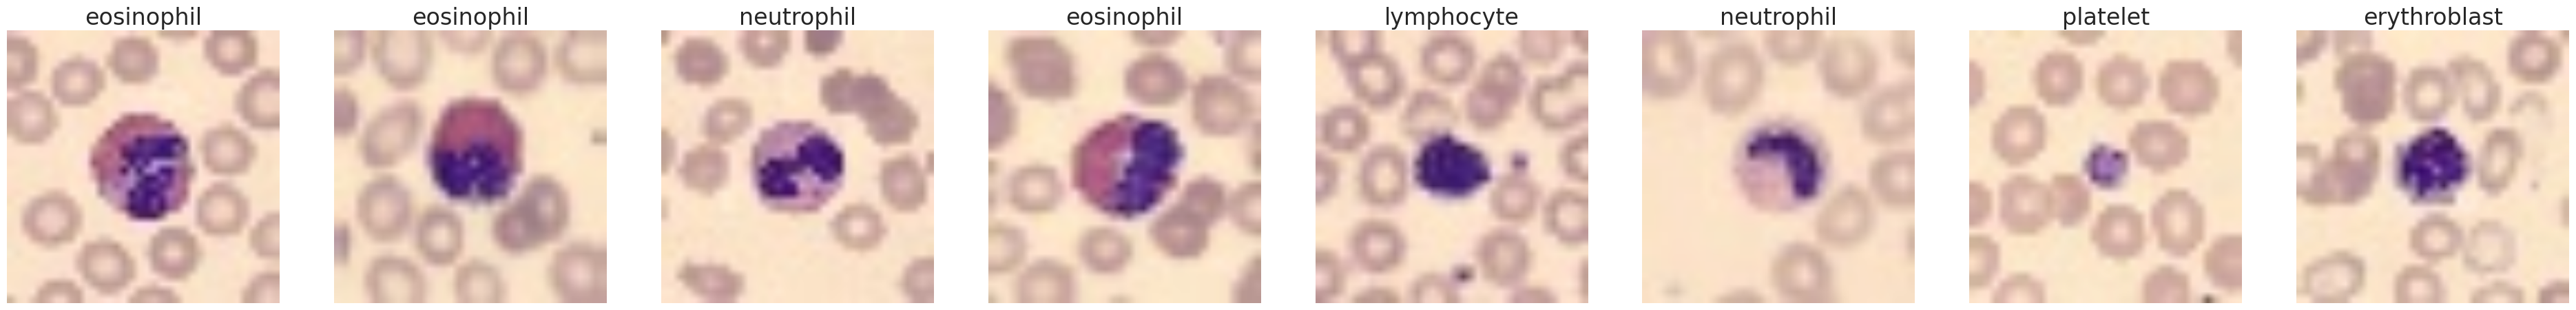

In [17]:
images, labels = next(iter(pipelineApprentissage))
nombresImages = 8
afficheDataset(images, labels,nombresImages,6*nombresImages,dictLabels,cmap=None)

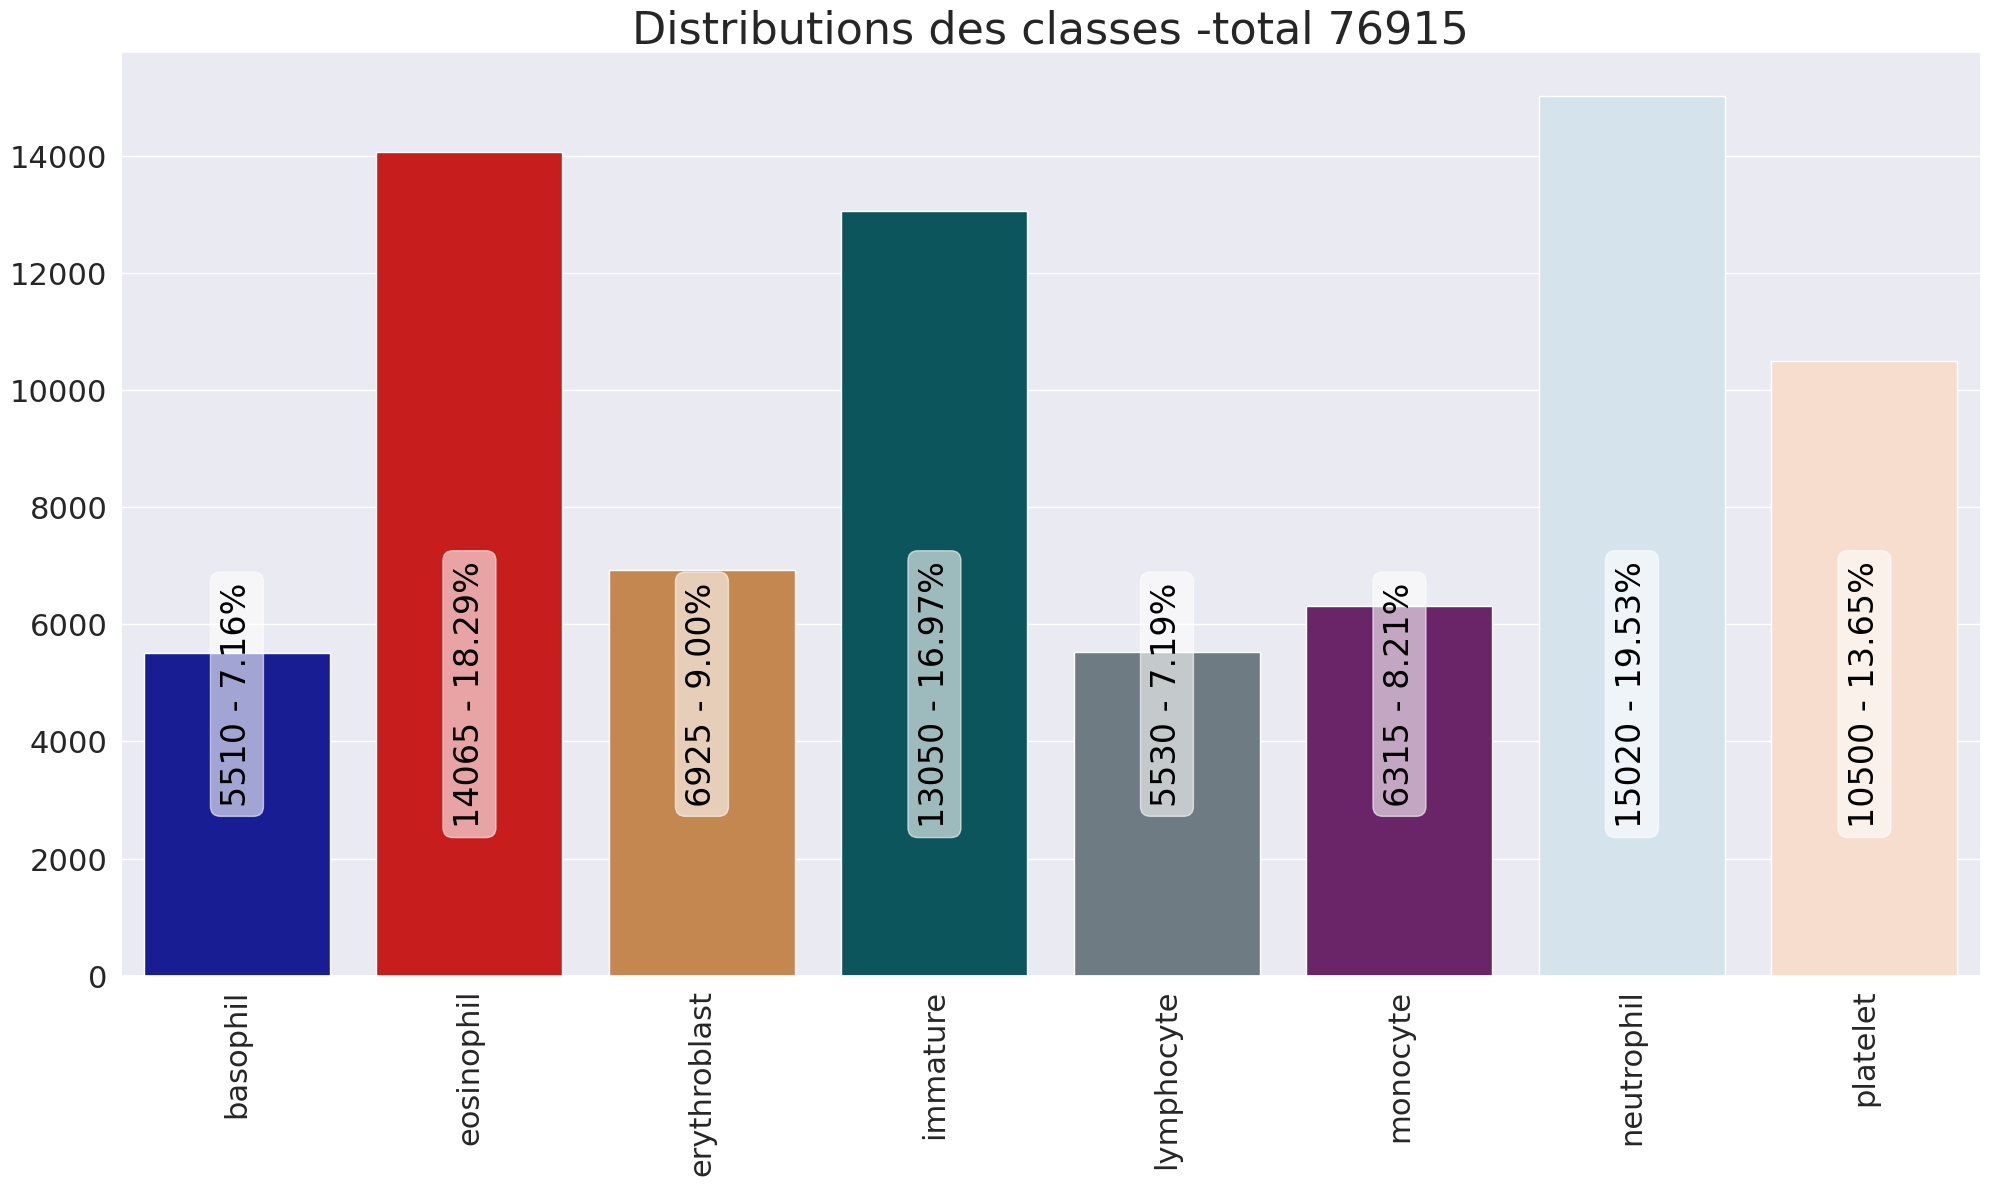

In [18]:
afficheDistributionsPipe(pipelineApprentissage, dictLabels, palette, repertoireEnregistrement=None)

### Re-Build Model for Flower Dataset

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Compilation du modèle pour le jeu de données</div></b>

In [24]:
# Re-Build Model
model = GCViT(**config, num_classes=nombreClasses)
inp = ops.array(np.random.uniform(size=(1, *image_size)))
out = model(inp)

# Load Weights
# ckpt_path = keras.utils.get_file(ckpt_link.split("/")[-1], ckpt_link)
# model.load_weights(ckpt_path, skip_mismatch=True)

model.compile(
    loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Entrainement du modèle</div></b>

L'évolution du taux d'apprentissage : du 0.0001 à 1.15e-06


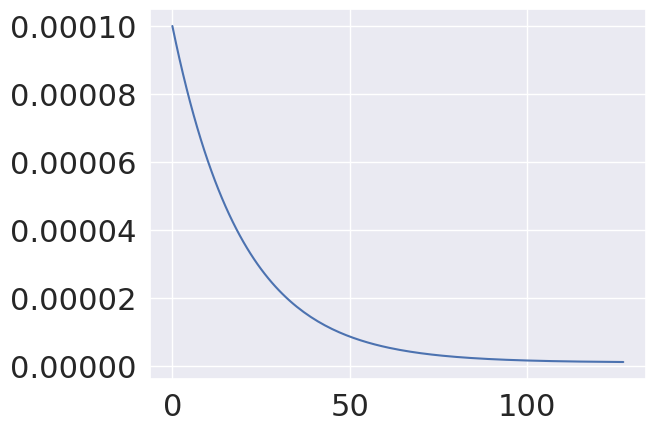

In [25]:
def evolutionTauxApprentissage(epoch,
                               initial_lrate=1e-04,
                               max_lrate=1e-04,
                               min_lrate=1e-06,
                               epochs_runup_lrate=0,
                               epochs_sustain_lrate=0,
                               drop_lrate=0.95):
    # epochs_drop = epochs * 0.1
    if epoch < epochs_runup_lrate:
        lrate = (max_lrate - initial_lrate) / epochs_runup_lrate * epoch + initial_lrate
    elif epoch < epochs_runup_lrate + epochs_sustain_lrate:
        lrate = max_lrate
    else:
        lrate = (max_lrate - min_lrate) * drop_lrate**(epoch - epochs_runup_lrate - epochs_sustain_lrate) + min_lrate
    return lrate

filename = os.path.join(repertoireModelSauvegarde, 'modelVLoss.weights.h5')
learningRate = keras.callbacks.LearningRateScheduler(evolutionTauxApprentissage)

checkpointLoss = keras.callbacks.ModelCheckpoint( filename, 
                                                   monitor = 'val_loss',
                                                   verbose = 1, 
                                                   save_best_only = True, 
                                                   save_weights_only=True,
                                                   mode = 'min')

backupAndRestore = keras.callbacks.BackupAndRestore(backup_dir=repertoireModelCKP, delete_checkpoint=False)
tensorBoard = keras.callbacks.TensorBoard(log_dir=repertoireModelLogs)

callbacks = [learningRate,checkpointLoss,backupAndRestore,tensorBoard]

rng = [i for i in range(epochs)]
y = [evolutionTauxApprentissage(x) for x in rng]
plt.plot(rng, y)

print(f"L'évolution du taux d'apprentissage : du {y[0]:.3g} à {min(y):.3g}")

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Entrainement du modèle</div></b>

In [26]:
history = model.fit( pipelineApprentissage, 
                     validation_data=pipelineValidation, 
                     epochs=epochs, 
                                  # batch_size=batch_size,
                     callbacks=callbacks,
                     verbose=2
                    )

Epoch 1/128


I0000 00:00:1757358452.800116  173188 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_loss improved from None to 0.32894, saving model to ../ResultatsExecutions/8-bloodMNIST-GCViTModel-160x160-bs32-epochs128/model.sauvegardes/sauvegarde/modelVLoss.weights.h5
2404/2404 - 354s - 147ms/step - accuracy: 0.7244 - loss: 0.7185 - val_accuracy: 0.8783 - val_loss: 0.3289 - learning_rate: 1.0000e-04
Epoch 2/128

Epoch 2: val_loss improved from 0.32894 to 0.28722, saving model to ../ResultatsExecutions/8-bloodMNIST-GCViTModel-160x160-bs32-epochs128/model.sauvegardes/sauvegarde/modelVLoss.weights.h5
2404/2404 - 153s - 64ms/step - accuracy: 0.9128 - loss: 0.2424 - val_accuracy: 0.9023 - val_loss: 0.2872 - learning_rate: 9.5050e-05
Epoch 3/128

Epoch 3: val_loss improved from 0.28722 to 0.18679, saving model to ../ResultatsExecutions/8-bloodMNIST-GCViTModel-160x160-bs32-epochs128/model.sauvegardes/sauvegarde/modelVLoss.weights.h5
2404/2404 - 153s - 64ms/step - accuracy: 0.9340 - loss: 0.1837 - val_accuracy: 0.9269 - val_loss: 0.1868 - learning_rate: 9.0348e-05
Epoch 4/1

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Sauvegarde de l'historique</div></b>

In [27]:
history = pd.DataFrame(model.history.history)
history.reset_index(inplace=True)
history.rename(columns={'index':'epoch'},inplace=True)
history.epoch += 1
history.to_parquet(os.path.join(repertoireSauvegardes,'sauvegardeHistorique.gzip'),compression='gzip', engine='pyarrow') 

In [28]:
history

,epoch,accuracy,loss,val_accuracy,val_loss,learning_rate
0,1,0.724371,0.718488,0.878291,0.328937,0.000100
1,2,0.912813,0.242394,0.902282,0.287224,0.000095
2,3,0.934044,0.183737,0.926858,0.186792,0.000090
3,4,0.945095,0.153840,0.923347,0.208613,0.000086
4,5,0.953130,0.131153,0.944412,0.152612,0.000082
...,...,...,...,...,...,...
123,124,0.999948,0.000067,0.968403,0.327981,0.000001
124,125,0.999948,0.000067,0.968403,0.328412,0.000001
125,126,0.999961,0.000089,0.966062,0.331856,0.000001
126,127,0.999961,0.000070,0.966062,0.333254,0.000001


In [30]:
historique = sauvegardeHistorique(model.history,
                                  repertoireSauvegardes,
                                  nomSauvegarde=f'historique-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}')

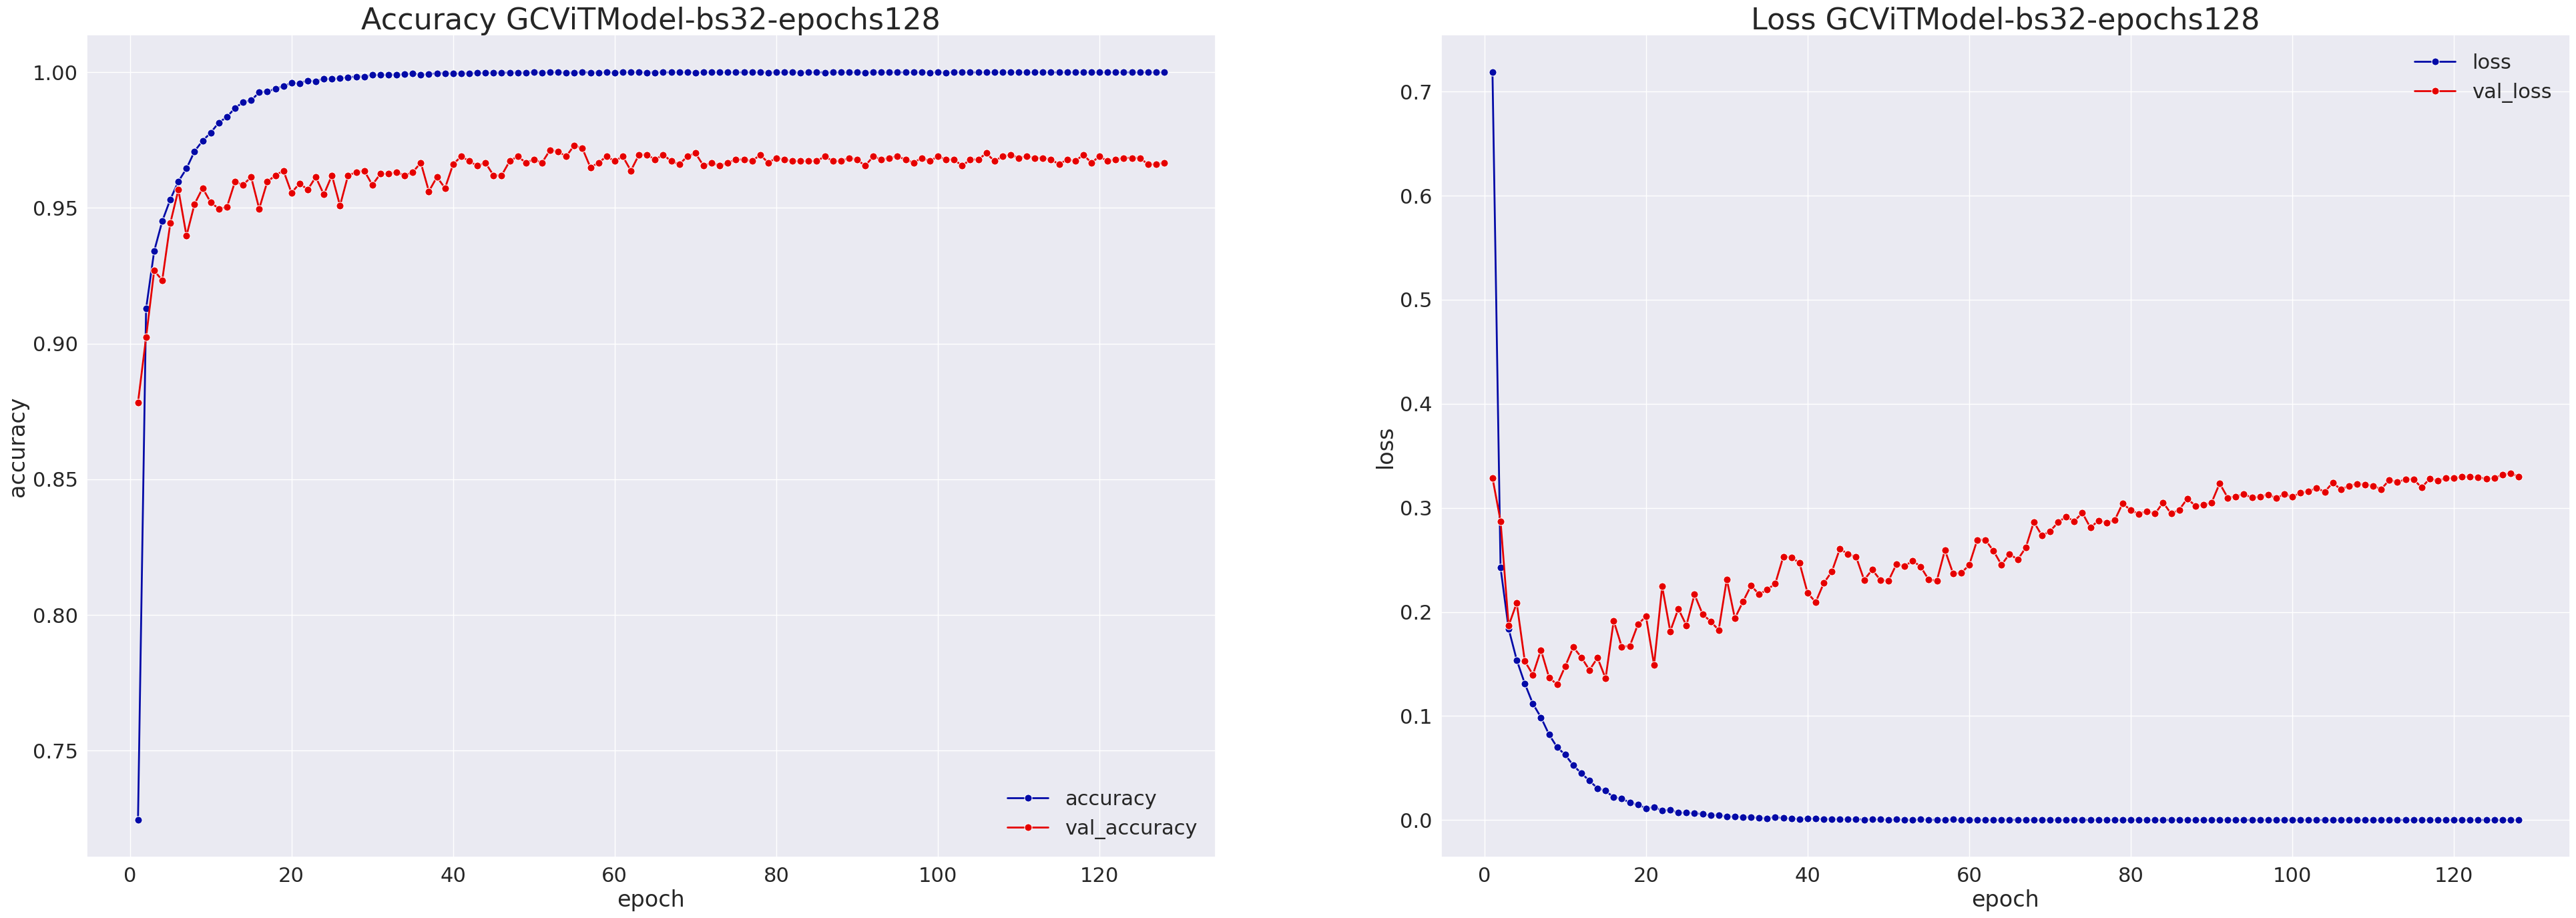

In [31]:
afficheHistoriqueEntrainement(historique, palette, f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}', repertoireEnregistrement)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Inférence</div></b>

In [32]:
for i, (img,lab) in enumerate(pipelineValidation): 
    images, labels = img if i==0 else tf.concat([images,img], 0), lab if i==0 else tf.concat([labels,lab], 0)

In [33]:
probabilities = model.predict(images, verbose=0)
predictions = np.argmax(probabilities, axis=-1)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Probabilités pour les 8 premiers prédictions </div></b>

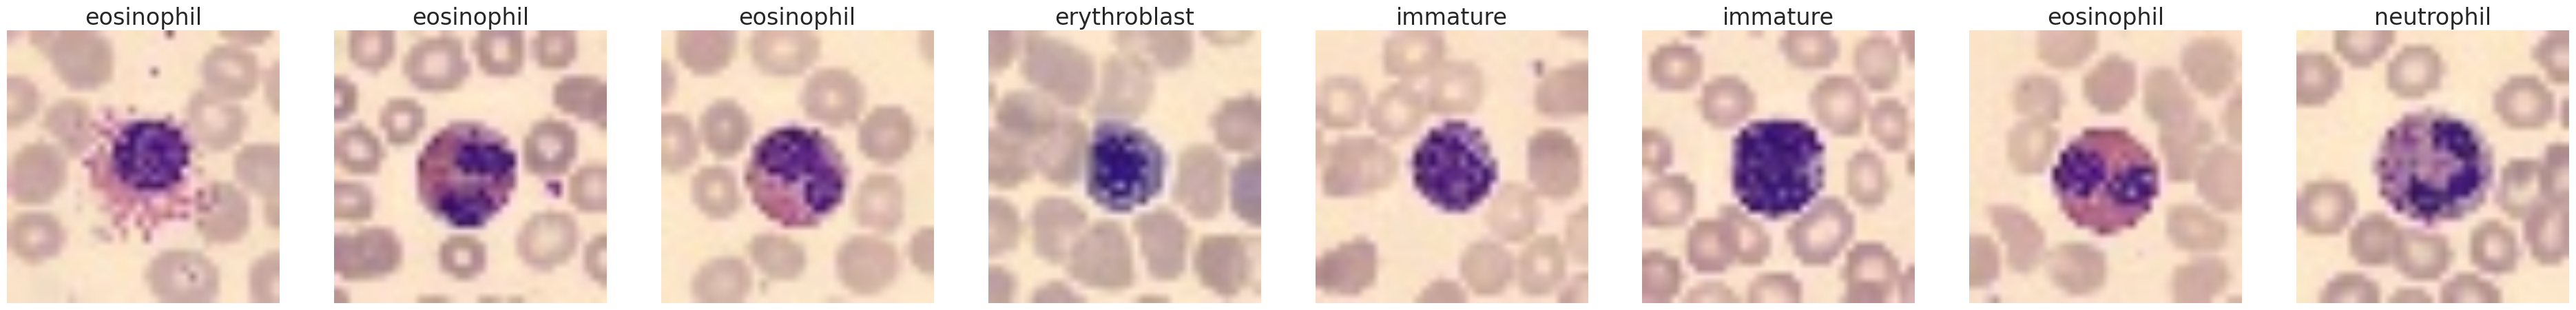

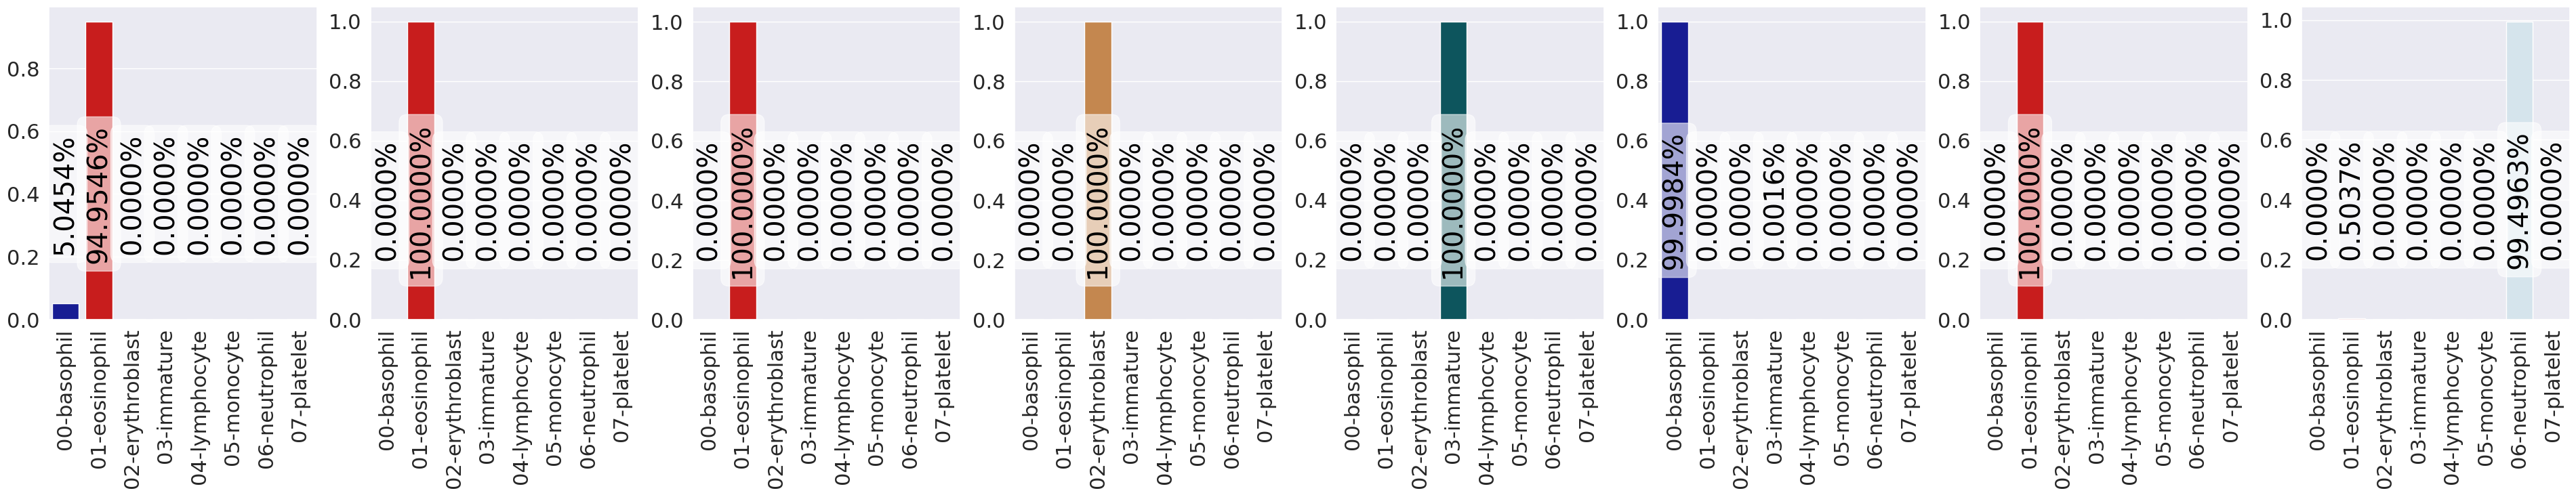

In [34]:
nombresImages = 8
afficheDataset(images, labels,nombresImages,6*nombresImages,dictLabels,cmap=None)
fig, ax = plt.subplots(nrows=1, ncols=nombresImages,figsize=(6*nombresImages,6));
for i in range(nombresImages):
    afficheProbabilites(probabilities,ind=i,ax=ax[i], dictLabels=dictLabels)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Matrice de Confusion </div></b>

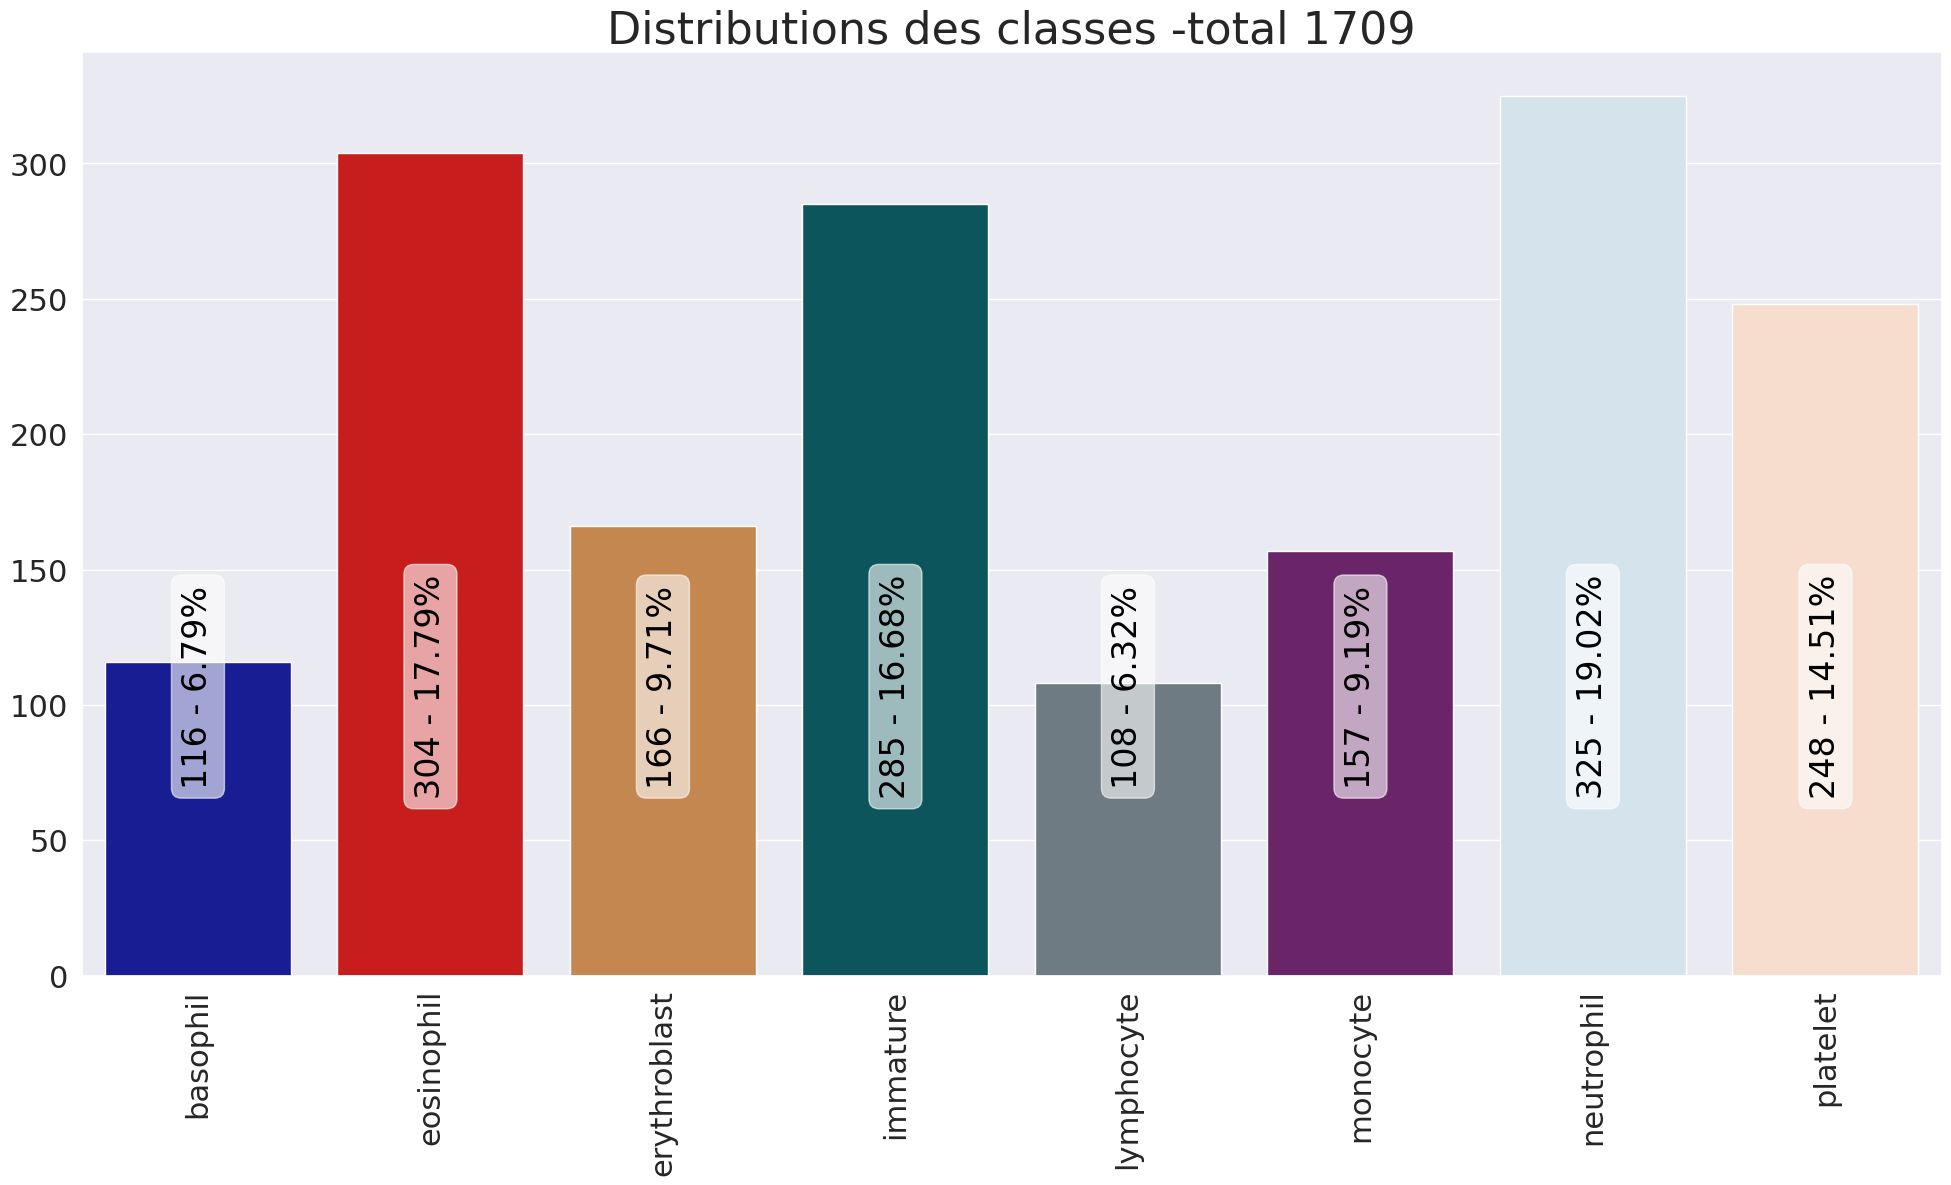

In [35]:
afficheDistributionsPipe(pipelineValidation, dictLabels, palette, repertoireEnregistrement=None)

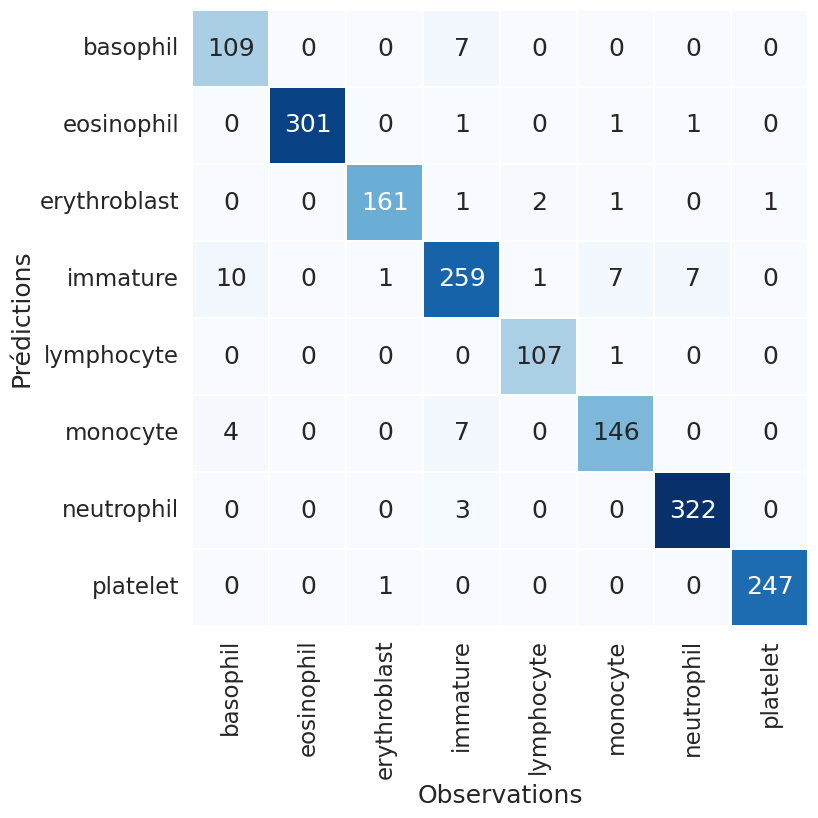

In [36]:
afficheMatriceConfusion(observations=labels,predictions=predictions,dictLabels=dictLabels, repertoireEnregistrement=repertoireEnregistrement,
                        nom_essai = f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}')

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Résultats de l’apprentissage</div></b>

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Area under the ROC curve : 0.9978	--	Exécution  :6.26s


,Classe,aucROC,avgPrecRec,f1,f2,f05,accuracy,precision,sensibilite,vrais_positifs,vrais_negatifs,faux_positifs,faux_negatifs,total_positifs,essai
0,global,0.997805,0.987511,0.966656,0.966625,0.966764,0.966647,0.966877,0.966647,1652,11906,57,57,1709,GCViTModel-bs32-epochs128
1,basophil,0.997116,0.950786,0.912134,0.928450,0.896382,0.987712,0.886179,0.939655,109,1579,14,7,116,GCViTModel-bs32-epochs128
2,eosinophil,0.999988,0.999946,0.995041,0.992090,0.998011,0.998245,1.000000,0.990132,301,1405,0,3,304,GCViTModel-bs32-epochs128
3,erythroblast,0.998727,0.995259,0.978723,0.973398,0.984108,0.995904,0.987730,0.969880,161,1541,2,5,166,GCViTModel-bs32-epochs128
4,immature,0.992410,0.957990,0.920071,0.913258,0.926986,0.973669,0.931655,0.908772,259,1405,19,26,285,GCViTModel-bs32-epochs128
5,lymphocyte,0.999902,0.998607,0.981651,0.987085,0.976277,0.997659,0.972727,0.990741,107,1598,3,1,108,GCViTModel-bs32-epochs128
6,monocyte,0.994975,0.971801,0.932907,0.931122,0.934699,0.987712,0.935897,0.929936,146,1542,10,11,157,GCViTModel-bs32-epochs128
7,neutrophil,0.999330,0.995605,0.983206,0.987730,0.978723,0.993563,0.975758,0.990769,322,1376,8,3,325,GCViTModel-bs32-epochs128
8,platelet,0.999994,0.999968,0.995968,0.995968,0.995968,0.998830,0.995968,0.995968,247,1460,1,1,248,GCViTModel-bs32-epochs128


<Figure size 1800x1800 with 0 Axes>

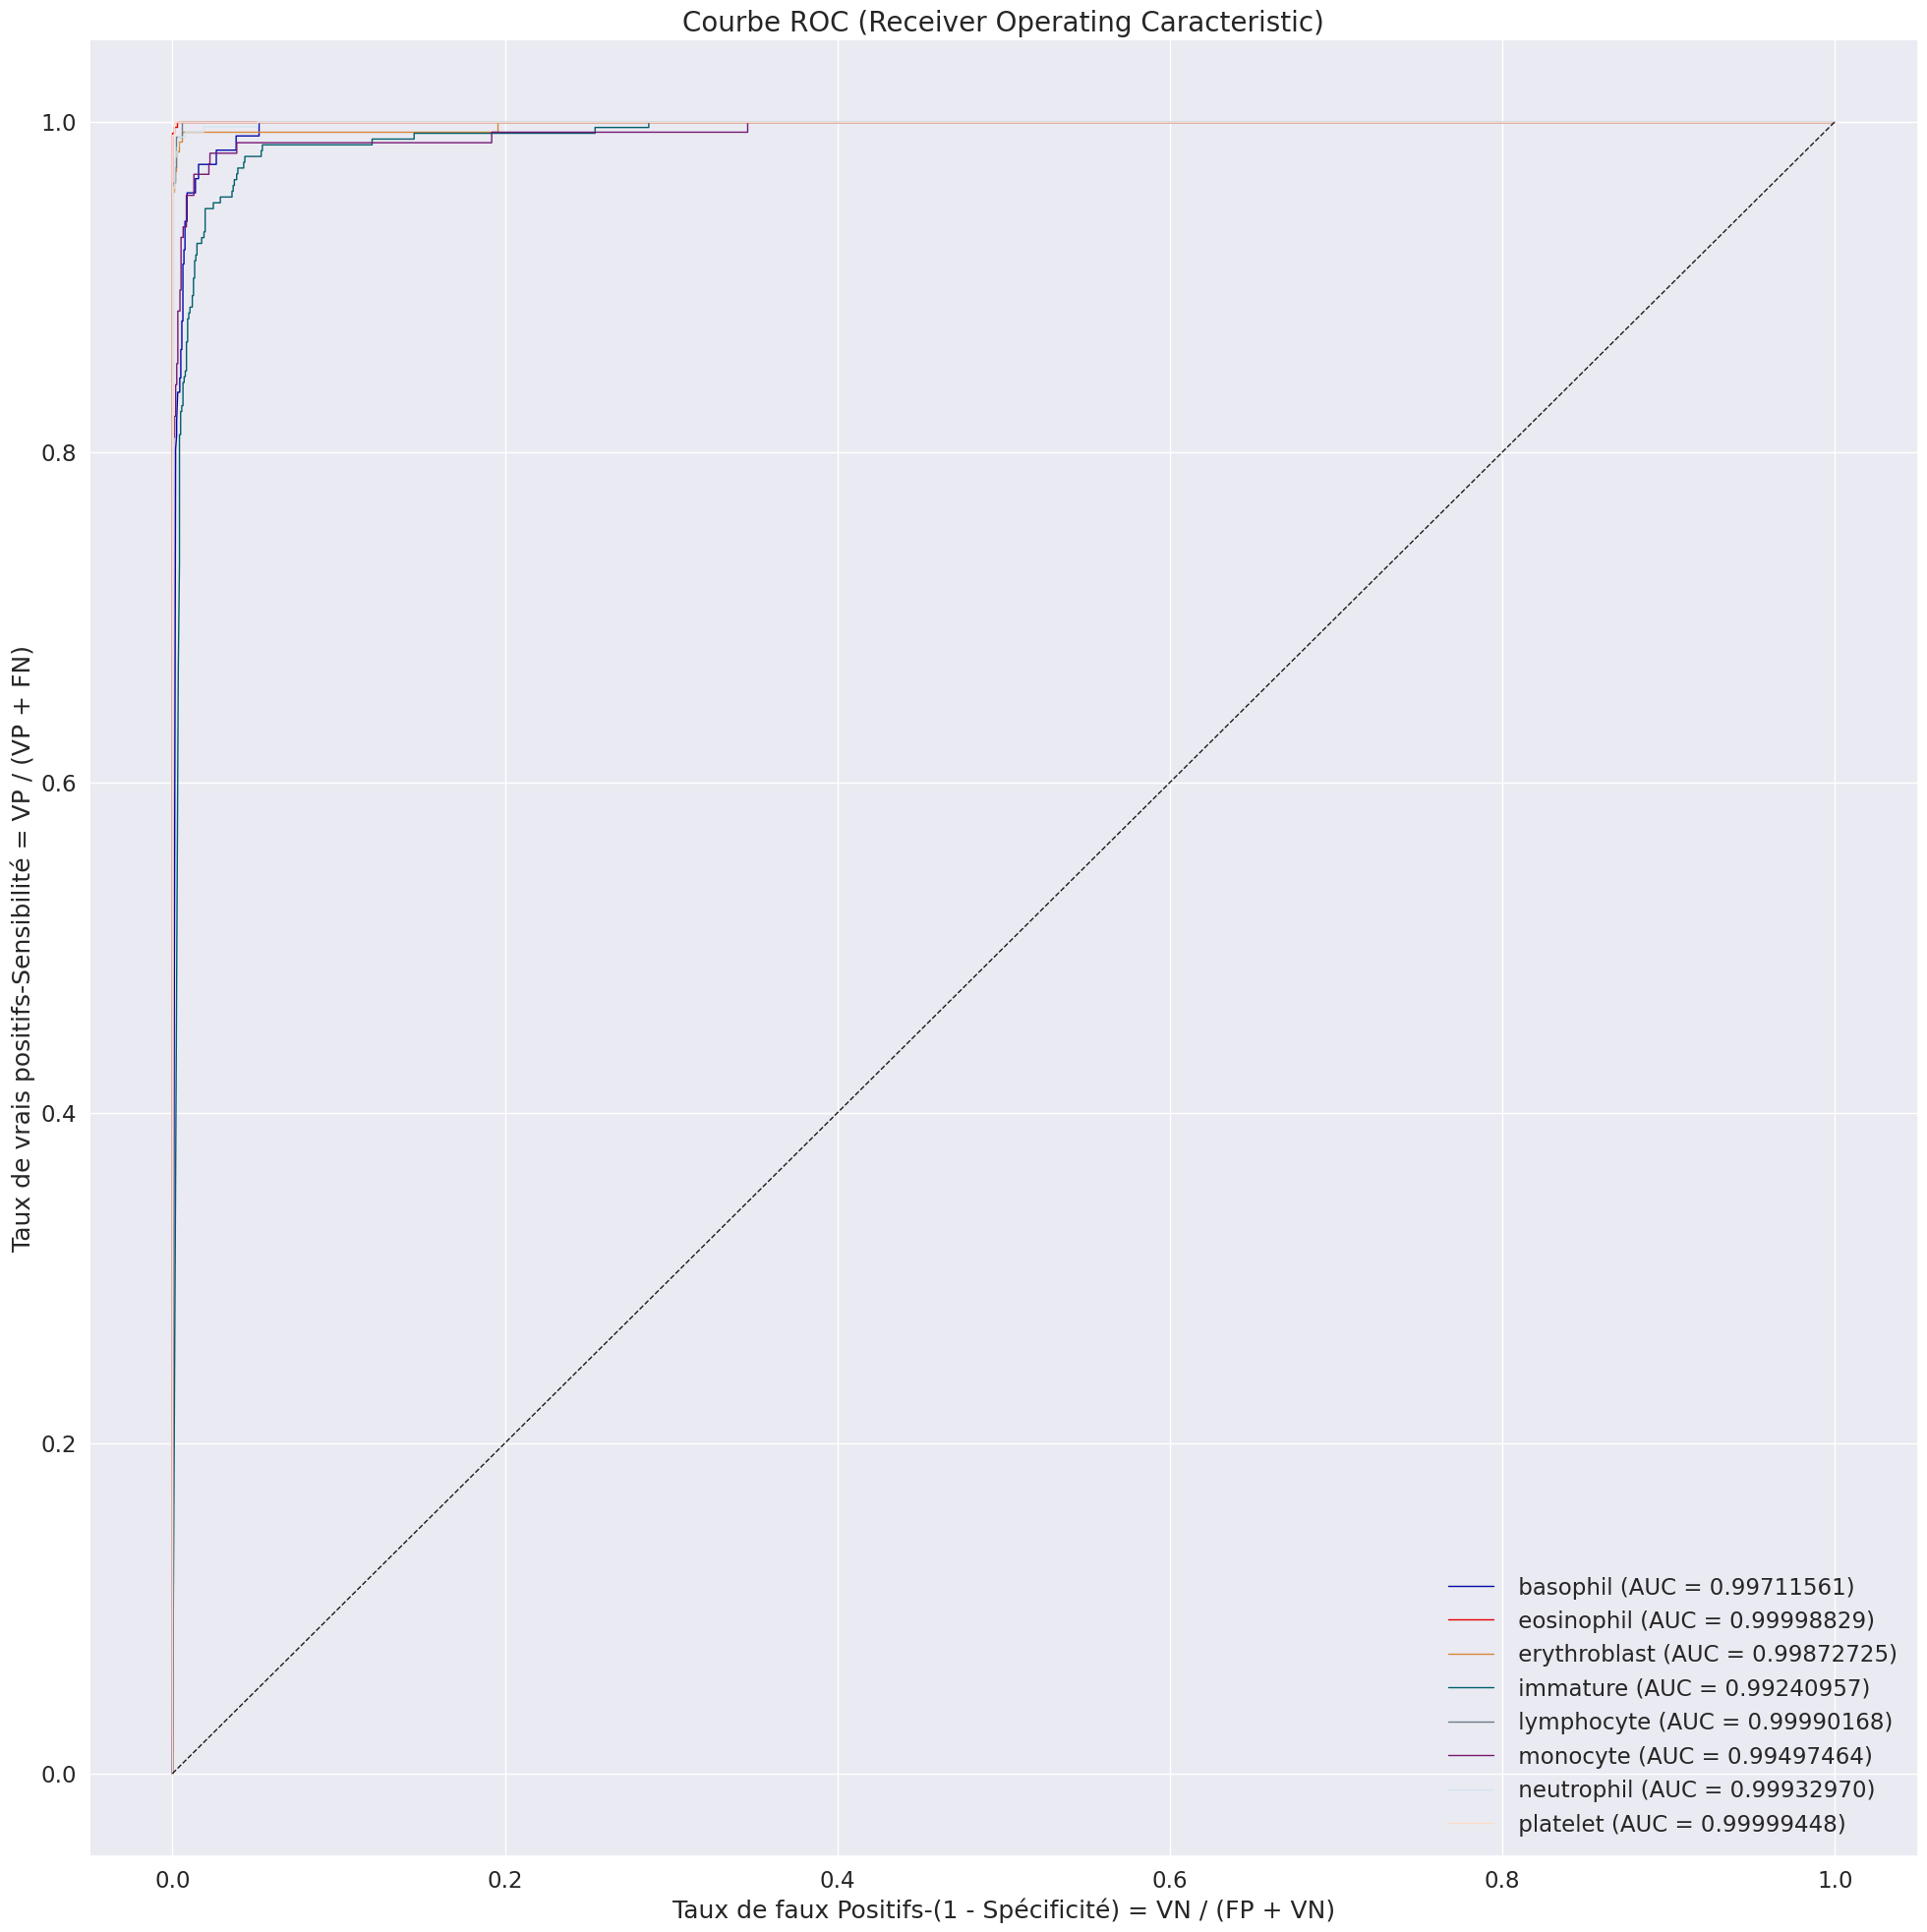

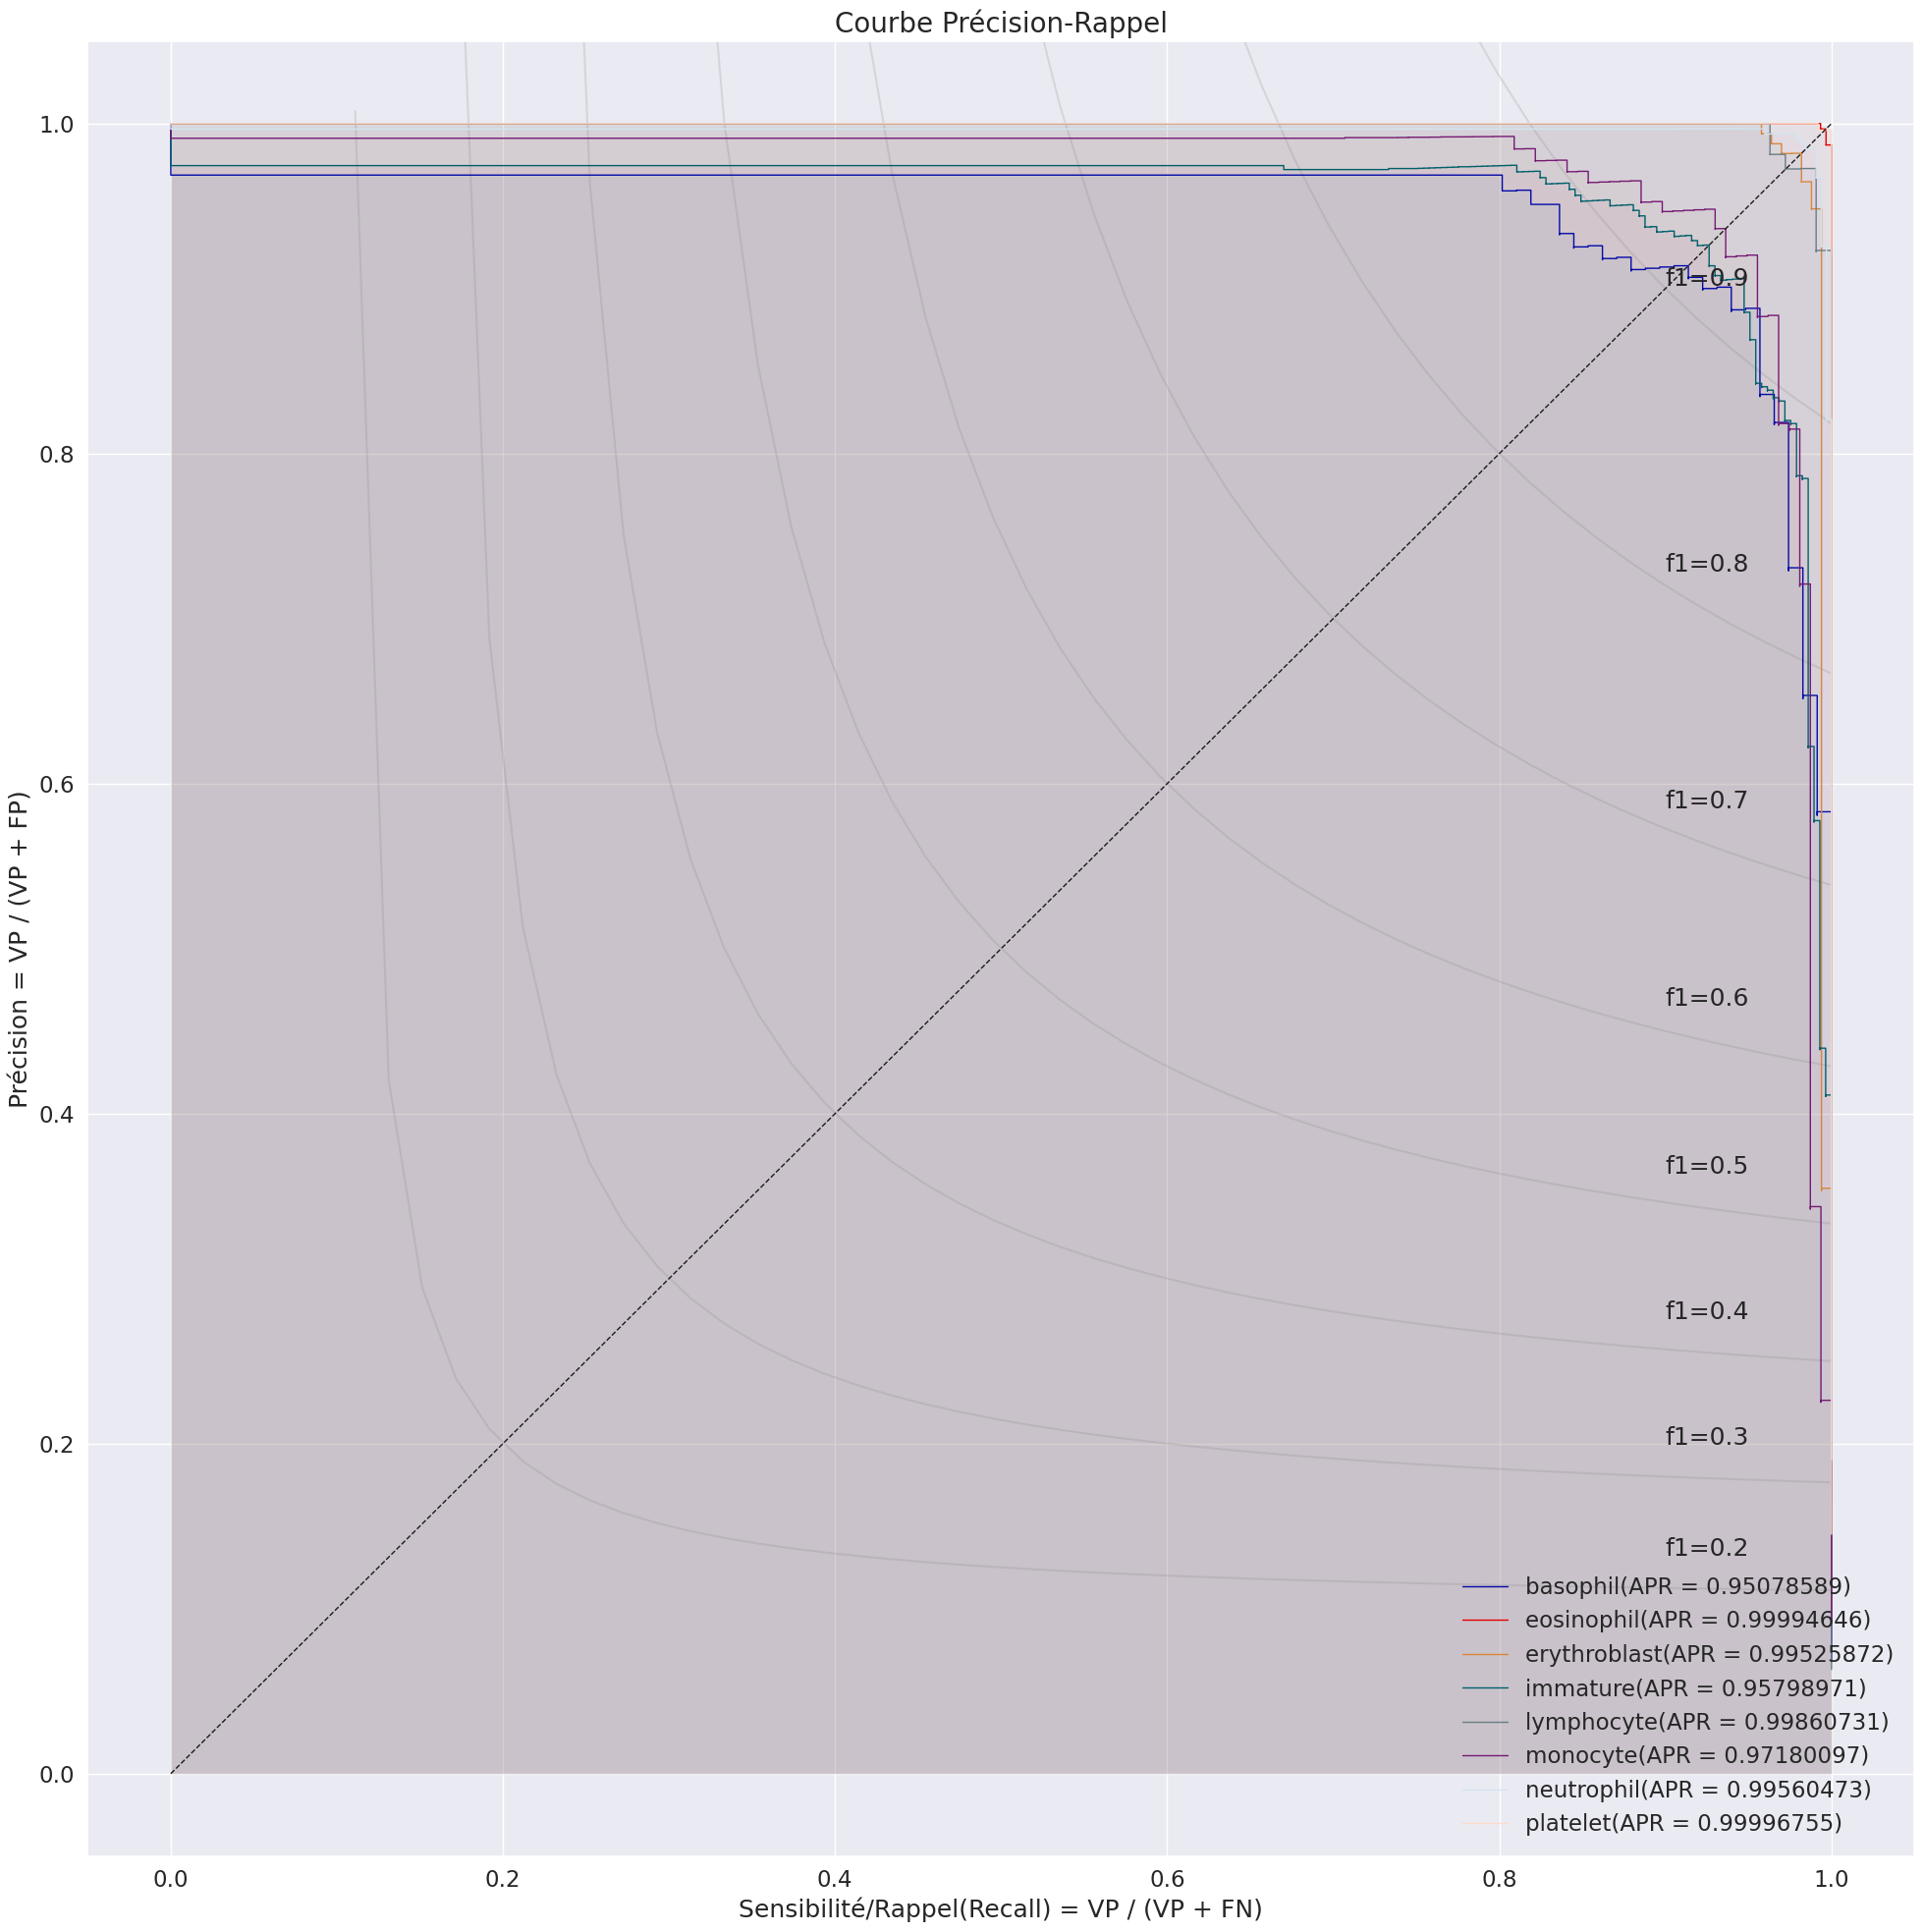

In [37]:
resultats = executeApprentissageChoixClassifieurs(
                                                  model,
                                                  X_test=images,
                                                  y_test=labels,
                                                  label_dict=dictLabels,
                                                  palette=palette, 
                                                  repertoireEnregistrement=repertoireEnregistrement,    
                                                  nom_essai = f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}',
                                                 );

resultats.to_parquet(os.path.join(repertoireSauvegardes,f'resultats-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}.gzip'),compression='gzip', engine='pyarrow')

resultats

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Reference</div></b>

* [gcvit-tf - A Python library for GCViT with TF2.0](https://github.com/awsaf49/gcvit-tf)
* [gcvit - Official codebase for GCViT](https://github.com/NVlabs/GCVit)